<a href="https://colab.research.google.com/github/SergeiVKalinin/MSE_Spring_2026/blob/main/Module%204/17_PINN_DiffusionEquation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Adapted from: https://github.com/huangboming/PDEs-PINN-Examples-Using-Tensorflow2/tree/main/Diffusion%20Equation

# Solving Diffusion Equation with PINN

Diffusion Equation:

$$u_t = u_{xx}  \quad x \in [-1, 1], t\in [0, 1]$$

Initial Condition: $$u(x, 0) = \sin(\pi x)$$
Boudary Conditions: $$u(-1, t) = u(1, t) = 0$$

In [1]:
!pip install keras==2.14.0 tensorflow==2.14.0

ERROR: Could not find a version that satisfies the requirement tensorflow==2.14.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.14.0


In [2]:
from matplotlib import pyplot as plt
import tensorflow as tf
import numpy as np

In [3]:
class Layer:
    """
    Define the structure of every layer.

    Paras:
      input_dim: size of input dataset
      output_dim: number of neurons
      activation: activation function, default: None(i.e. without activation function)

    Properties:
      activation: activation function
      W, b: weights of the layer
      weights: a list that contains W and b

    You can just call a layer to execute the progress called "forward pass"
    """
    def __init__(self, input_dim, output_dim, activation=None):
        self.activation = activation

        # initial weights
        std = np.sqrt(2 / (input_dim + output_dim))
        self.W = tf.Variable(initial_value=tf.random.normal(shape=(input_dim, output_dim), stddev=std))
        self.b = tf.Variable(initial_value=tf.zeros(shape=(output_dim, )))

    def __call__(self, inputs):
        # forward pass
        if self.activation:
            return self.activation(tf.matmul(inputs, self.W) + self.b)
        else:
            # If the layer don't have an activation, go linear combination directly
            return tf.matmul(inputs, self.W) + self.b

    @property
    def weights(self):
        # define "weight" property
        return [self.W, self.b]

class Model:
    """
    Define the model

    Parameters:
      layers: a list of Layer
      xmin, xmax: the range of the PDE

    Properties:
      layers: a list of Layer
      train_min, train_max: the range of the PDE
      weights: a list that contains weights of each layer

    You can call the model to calculate the result based on given dataset
    """
    def __init__(self, layers, train_min, train_max):
        self.layers = layers
        self.train_min = train_min
        self.train_max = train_max

    def __call__(self, training_set):
        x = training_set
        x = 2.0 * (x - self.train_min) / (self.train_max - self.train_min) - 1.0
        for layer in self.layers:
            # update inputs
            x = layer(x)
        return x

    @property
    def weights(self):
        weights = []
        for layer in self.layers:
            weights += layer.weights
        return weights

In [4]:
'''
def train_step(model, optimizer, X_train, X_train_IC,
               X_train_BC_bottom, X_train_BC_top, w1=1, w2=1):
    """
    One training step using SGD.

    Parameters:
      model: an NN/DNN model
      optimizer: a Keras optimizer
      X_train: training set for the pde
      X_train_IC: training set for initial condition
      X_train_BC_bottom, X_train_BC_top: training set for boundary condition
      w1, w2: weights for pde loss and IC/BC loss

    Return:
      loss: loss score after training
    """

    # Calculate loss
    with tf.GradientTape() as utter_tape:
        with tf.GradientTape(persistent=True) as outer_tape:
            with tf.GradientTape(persistent=True) as inner_tape:
                x = X_train[:, 0]
                t = X_train[:, 1]
                # tf.stack([x, t], axis=1) <=> X_train
                u = model(tf.stack([x, t], axis=1))
            u_x = inner_tape.gradient(u, x)
            u_t = inner_tape.gradient(u, t)
        u_xx = outer_tape.gradient(u_x, x)

        f = 0 #-tf.exp(-t) * (tf.sin(np.pi * x) - np.pi**2 * tf.sin(np.pi * x))

        # loss of the PDE
        loss_f = tf.reduce_mean(tf.square(u_t - u_xx - f))

        # loss of IC
        u_pred_IC = model(X_train_IC)
        u_IC = np.sin(np.pi * X_train_IC[:, 0])[:, None]**2
        loss_IC = tf.reduce_mean(tf.square(u_pred_IC - u_IC))

        # loss of BCs
        u_pred_BC_bottom = model(X_train_BC_bottom)
        u_pred_BC_top = model(X_train_BC_top)
        loss_BC_bottom = tf.reduce_mean(tf.square(u_pred_BC_bottom - 0))
        loss_BC_top = tf.reduce_mean(tf.square(u_pred_BC_top - 0))

        # total loss
        loss = w1 * loss_f + w2 * (loss_IC + loss_BC_bottom + loss_BC_top)

    # optimize with optimizer
    optimizer.minimize(loss, model.weights, tape=utter_tape)
    return loss

def train_model(model, X_train, X_train_IC,
               X_train_BC_bottom, X_train_BC_top, w1=1, w2=1, epochs=1000, learning_rate=0.0008, warning=False):
    """
    Train neural network model.

    Parameters:
      model: a neural network model
      X_train: training set for the pde
      X_train_IC: training set for initial condition
      X_train_BC_bottom, X_train_BC_top: training set for boundary condition
      w1, w2: weights for pde loss and IC/BC loss
      epochs: epochs, i.e. times of training, default: 1000
      learning_rate: learning rate of SGD, default: 0.0008
      warning: whether to show loss score of each epoch, default: False

    Return value:
      history_loss: a list that contains loss score at each step
    """

    history_loss = []
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    for epoch in range(epochs):
        loss = train_step(model, optimizer, X_train, X_train_IC, X_train_BC_bottom, X_train_BC_top, w1, w2)
        history_loss.append(loss)

        if warning:
          if epoch%100 == 0:
            print(f'epoch: {epoch + 1}, loss: {loss:.5f}')

    return history_loss
    '''

'\ndef train_step(model, optimizer, X_train, X_train_IC,\n               X_train_BC_bottom, X_train_BC_top, w1=1, w2=1):\n    """\n    One training step using SGD.\n\n    Parameters:\n      model: an NN/DNN model\n      optimizer: a Keras optimizer\n      X_train: training set for the pde\n      X_train_IC: training set for initial condition\n      X_train_BC_bottom, X_train_BC_top: training set for boundary condition\n      w1, w2: weights for pde loss and IC/BC loss\n\n    Return:\n      loss: loss score after training\n    """\n\n    # Calculate loss\n    with tf.GradientTape() as utter_tape:\n        with tf.GradientTape(persistent=True) as outer_tape:\n            with tf.GradientTape(persistent=True) as inner_tape:\n                x = X_train[:, 0]\n                t = X_train[:, 1]\n                # tf.stack([x, t], axis=1) <=> X_train\n                u = model(tf.stack([x, t], axis=1))\n            u_x = inner_tape.gradient(u, x)\n            u_t = inner_tape.gradient(u, t)\

In [5]:
import tensorflow as tf
import numpy as np

PI = tf.constant(np.pi, dtype=tf.float32)

def train_step(model, optimizer, X_train, X_train_IC,
               X_train_BC_bottom, X_train_BC_top, w1=1, w2=1):
    """
    One training step. Output matches original: returns scalar `loss` (tf.Tensor).
    """

    # Ensure tensors
    X_train = tf.convert_to_tensor(X_train, dtype=tf.float32)
    X_train_IC = tf.convert_to_tensor(X_train_IC, dtype=tf.float32)
    X_train_BC_bottom = tf.convert_to_tensor(X_train_BC_bottom, dtype=tf.float32)
    X_train_BC_top = tf.convert_to_tensor(X_train_BC_top, dtype=tf.float32)

    w1 = tf.cast(w1, tf.float32)
    w2 = tf.cast(w2, tf.float32)

    with tf.GradientTape() as utter_tape:
        x = X_train[:, 0:1]
        t = X_train[:, 1:2]

        # Derivatives wrt x,t: must watch x,t explicitly
        with tf.GradientTape(persistent=True) as outer_tape:
            outer_tape.watch(x)
            with tf.GradientTape(persistent=True) as inner_tape:
                inner_tape.watch([x, t])
                u = model(tf.concat([x, t], axis=1))
            u_x = inner_tape.gradient(u, x)
            u_t = inner_tape.gradient(u, t)
        u_xx = outer_tape.gradient(u_x, x)

        del inner_tape
        del outer_tape

        f = tf.zeros_like(u)

        loss_f = tf.reduce_mean(tf.square(u_t - u_xx - f))

        u_pred_IC = model(X_train_IC)
        x_ic = X_train_IC[:, 0:1]
        u_IC = tf.square(tf.sin(PI * x_ic))
        loss_IC = tf.reduce_mean(tf.square(u_pred_IC - u_IC))

        u_pred_BC_bottom = model(X_train_BC_bottom)
        u_pred_BC_top = model(X_train_BC_top)
        loss_BC_bottom = tf.reduce_mean(tf.square(u_pred_BC_bottom - 0.0))
        loss_BC_top = tf.reduce_mean(tf.square(u_pred_BC_top - 0.0))

        loss = w1 * loss_f + w2 * (loss_IC + loss_BC_bottom + loss_BC_top)

    # --- FIX: choose variables robustly (trainable_variables may not exist) ---
    if hasattr(model, "trainable_variables"):
        var_list = model.trainable_variables
    elif hasattr(model, "trainable_weights"):
        var_list = model.trainable_weights
    else:
        var_list = model.weights  # fallback (closest to your original)

    grads = utter_tape.gradient(loss, var_list)
    optimizer.apply_gradients(zip(grads, var_list))

    return loss


def train_model(model, X_train, X_train_IC,
               X_train_BC_bottom, X_train_BC_top, w1=1, w2=1,
               epochs=1000, learning_rate=0.0008, warning=False):
    """
    Output matches original: returns history_loss list of tf.Tensors.
    """
    history_loss = []
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    for epoch in range(epochs):
        loss = train_step(model, optimizer, X_train, X_train_IC,
                          X_train_BC_bottom, X_train_BC_top, w1, w2)
        history_loss.append(loss)

        if warning and (epoch % 100 == 0):
            print(f'epoch: {epoch + 1}, loss: {float(loss.numpy()):.5f}')

    return history_loss

# Training Data

In [6]:
# Training data for pde
xmin = -1.0
xmax = 1.0
tmin = 0
tmax = 1.0
pde_point_count = 800

x = xmin + (xmax - xmin) * np.random.rand(pde_point_count, 1)
t = tmin + (tmax - tmin) * np.random.rand(pde_point_count, 1)

X_train = tf.Variable(np.hstack((x, t)), dtype='float32')
train_min = np.hstack((xmin, tmin))
train_max = np.hstack((xmax, tmax))

# Training data for initial condition
ic_point_count = 10

b_x = xmin + (xmax - xmin) * np.random.rand(ic_point_count, 1)
X_train_IC = tf.Variable(np.hstack((b_x, np.zeros_like(b_x))), dtype='float32')

# Training data for boundary conditions
bc_point_count_each = 10

b_t = tmin + (tmax - tmin) * np.random.rand(bc_point_count_each, 1)
X_train_BC_bottom = tf.Variable(np.hstack((np.ones_like(b_t) * xmin, b_t)), dtype="float32")
X_train_BC_top = tf.Variable(np.hstack((np.ones_like(b_t) * xmax, b_t)), dtype="float32")

In [7]:
b_x.shape, x.shape, t.shape

((10, 1), (800, 1), (800, 1))

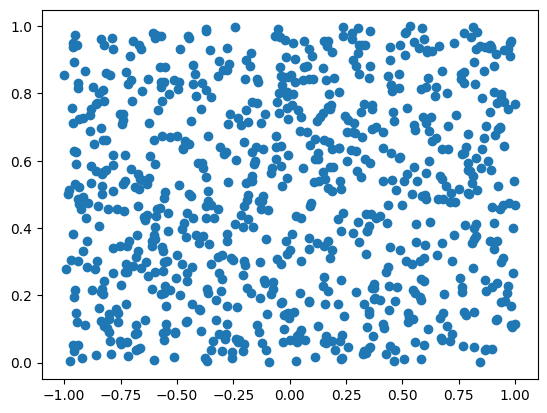

In [8]:
plt.scatter(x,t)

In [9]:
# DNN model
model = Model([
    Layer(input_dim=2, output_dim=32, activation=tf.nn.tanh),
    Layer(input_dim=32, output_dim=64, activation=tf.nn.tanh),
    Layer(input_dim=64, output_dim=32, activation=tf.nn.tanh),
    Layer(input_dim=32, output_dim=1, activation=None)
], train_min, train_max)

epoch: 1, loss: 0.27652
epoch: 101, loss: 0.18040
epoch: 201, loss: 0.16489
epoch: 301, loss: 0.14807
epoch: 401, loss: 0.12932
epoch: 501, loss: 0.11187
epoch: 601, loss: 0.10195
epoch: 701, loss: 0.09641
epoch: 801, loss: 0.09266
epoch: 901, loss: 0.09007
epoch: 1001, loss: 0.08812
epoch: 1101, loss: 0.08660
epoch: 1201, loss: 0.08535
epoch: 1301, loss: 0.08434
epoch: 1401, loss: 0.08341
epoch: 1501, loss: 0.08252
epoch: 1601, loss: 0.08161
epoch: 1701, loss: 0.08088
epoch: 1801, loss: 0.08022
epoch: 1901, loss: 0.07974
epoch: 2001, loss: 0.07932
epoch: 2101, loss: 0.07904
epoch: 2201, loss: 0.07869
epoch: 2301, loss: 0.07861
epoch: 2401, loss: 0.07838
epoch: 2501, loss: 0.07830
epoch: 2601, loss: 0.07820
epoch: 2701, loss: 0.07803
epoch: 2801, loss: 0.07793
epoch: 2901, loss: 0.07785
epoch: 3001, loss: 0.07770
epoch: 3101, loss: 0.07757
epoch: 3201, loss: 0.07753
epoch: 3301, loss: 0.07739
epoch: 3401, loss: 0.07733
epoch: 3501, loss: 0.07717
epoch: 3601, loss: 0.07703
epoch: 3701, 

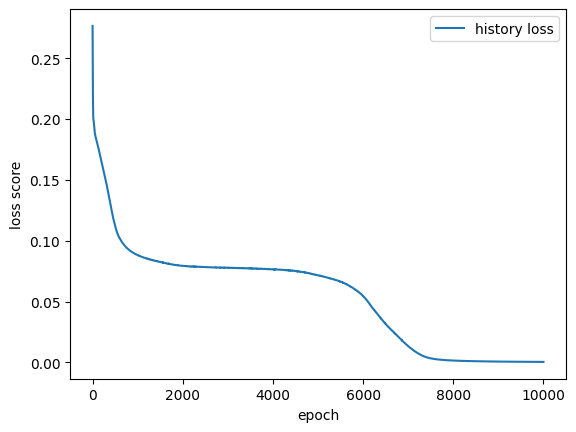

Final loss score: 0.00035747059155255556


In [10]:
# train the model
epochs = 10000
history_loss = train_model(model, X_train, X_train_IC, X_train_BC_bottom, X_train_BC_top,
                           w1=0.3, w2=0.8, epochs=epochs,
                          learning_rate=1e-4, warning=True)

# plot loss score in each epoch
plt.plot(np.array(range(epochs)) + 1, history_loss, label='history loss')
plt.xlabel('epoch')
plt.ylabel('loss score')
plt.legend()
plt.show()
plt.close()

print(f'Final loss score: {history_loss[-1]}')

epoch: 1, loss: 0.00036
epoch: 101, loss: 0.00034
epoch: 201, loss: 0.00033
epoch: 301, loss: 0.00033
epoch: 401, loss: 0.00032
epoch: 501, loss: 0.00030
epoch: 601, loss: 0.00030
epoch: 701, loss: 0.00027
epoch: 801, loss: 0.00027
epoch: 901, loss: 0.00026
epoch: 1001, loss: 0.00025
epoch: 1101, loss: 0.00024
epoch: 1201, loss: 0.00023
epoch: 1301, loss: 0.00021
epoch: 1401, loss: 0.00021
epoch: 1501, loss: 0.00020
epoch: 1601, loss: 0.00021
epoch: 1701, loss: 0.00020
epoch: 1801, loss: 0.00020
epoch: 1901, loss: 0.00019
epoch: 2001, loss: 0.00017
epoch: 2101, loss: 0.00017
epoch: 2201, loss: 0.00017
epoch: 2301, loss: 0.00016
epoch: 2401, loss: 0.00016
epoch: 2501, loss: 0.00016
epoch: 2601, loss: 0.00015
epoch: 2701, loss: 0.00015
epoch: 2801, loss: 0.00015
epoch: 2901, loss: 0.00014
epoch: 3001, loss: 0.00014
epoch: 3101, loss: 0.00013
epoch: 3201, loss: 0.00014
epoch: 3301, loss: 0.00013
epoch: 3401, loss: 0.00013
epoch: 3501, loss: 0.00013
epoch: 3601, loss: 0.00013
epoch: 3701, 

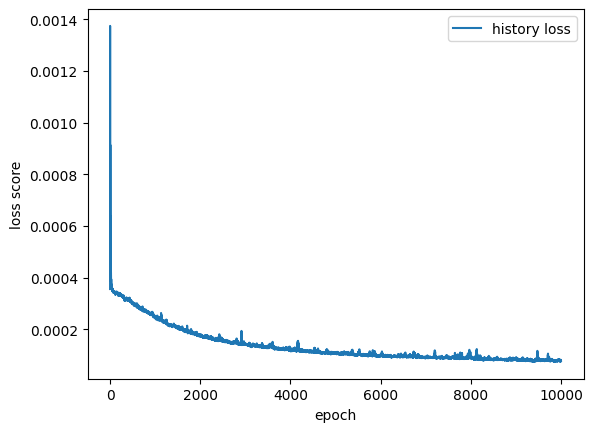

Final loss score: 7.854926e-05


In [11]:
# train the model
epochs = 10000
history_loss = train_model(
    model,
    X_train, X_train_IC, X_train_BC_bottom, X_train_BC_top,
    w1=0.3, w2=0.8,
    epochs=epochs,
    learning_rate=1e-4,
    warning=True
)

# history_loss is a list of tf.Tensors (same as original code),
# so convert to floats for plotting/printing.
history_loss_f = np.array([float(l.numpy()) for l in history_loss], dtype=float)

# plot loss score in each epoch
plt.plot(np.arange(1, epochs + 1), history_loss_f, label='history loss')
plt.xlabel('epoch')
plt.ylabel('loss score')
plt.legend()
plt.show()
plt.close()

print(f'Final loss score: {history_loss_f[-1]:.6e}')

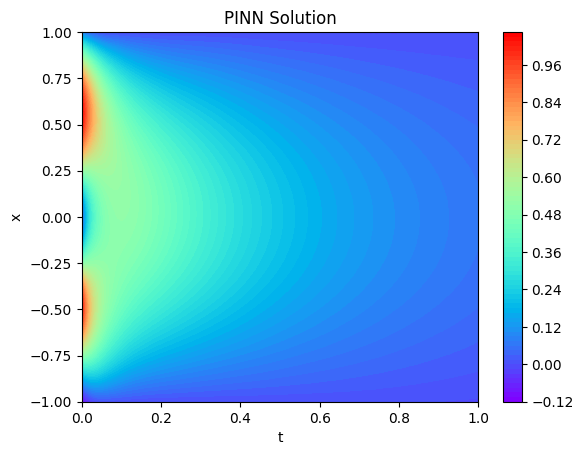

In [12]:
# plot results

x_test = np.linspace(-1, 1, 200).reshape((-1, 1))
t_test = np.linspace(0, 1, 200).reshape((-1, 1))
x_t, t_t = np.meshgrid(x_test, t_test)

# PINN solution

X_test = tf.Variable(np.hstack((x_t.reshape((-1, 1)), t_t.reshape((-1, 1)))), dtype="float32")
u_pred = model(X_test)
u_pred = tf.reshape(u_pred, (200, 200))

fig, ax = plt.subplots(1, 1)
cp = ax.contourf(t_t, x_t, u_pred, 100, cmap="rainbow")
fig.colorbar(cp)
ax.set_title('PINN Solution')
ax.set_xlabel('t')
ax.set_ylabel('x')
plt.show()